In [1]:
import math


ARM_LENGTH = 5.0
ARM_MASS = 5.0

WHEEL_MASS = 8.0
WHEEL_RADIUS = 2.0

STARTING_ARM_THETA = math.radians(45) # in rad

GRAVITY = -9.8
FRICTION = 1.5

DT = 0.001


KP = 0.3
KD = 0.3
KI = 0.1


# so arm theta -> wheel torque -> arm atheta -> arm vtheta -> arm theta
# PID would control wheel torque - the error would be desired arm theta - measured arm theta


class System:

    def __init__(self, arm_length, arm_mass, arm_theta):

        self.arm_length = arm_length
        self.arm_mass = arm_mass
        self.arm_theta = arm_theta
        
        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2)
        self.arm_torque = self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)
        
        self.arm_atheta = 3/(2 * self.arm_length) * GRAVITY * math.sin(self.arm_theta)
        self.arm_vtheta = 0

        self.arm_thetas = []
        self.arm_vthetas = []
        self.arm_athetas = []


    def solve_for_theta(self):
        
        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2)
        self.arm_torque = self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)

        self.arm_atheta = (self.arm_torque + FRICTION * (-1 if self.arm_vtheta > 0 else 1)) / self.arm_moment
        self.arm_vtheta = self.arm_vtheta + self.arm_atheta * DT
        self.arm_theta = self.arm_theta + self.arm_vtheta * DT

        self.arm_athetas.append(self.arm_atheta)
        self.arm_vthetas.append(self.arm_vtheta)
        self.arm_thetas.append(self.arm_theta)


    def loop(self):
        for i in range(100000):
            self.solve_for_theta()





In [2]:
pendulum = System(ARM_LENGTH, ARM_MASS, STARTING_ARM_THETA)
pendulum.loop()

In [3]:
pendulum.arm_thetas[-1]

0.00019462041580265007

saved -> pendulum.gif
  window 0.0-20.0s of 100s sim | 1x speed | 600 frames @ 30fps = 20.0s clip | 33 ms sim/frame
  (showing first 20s only. For the whole run: full=True)


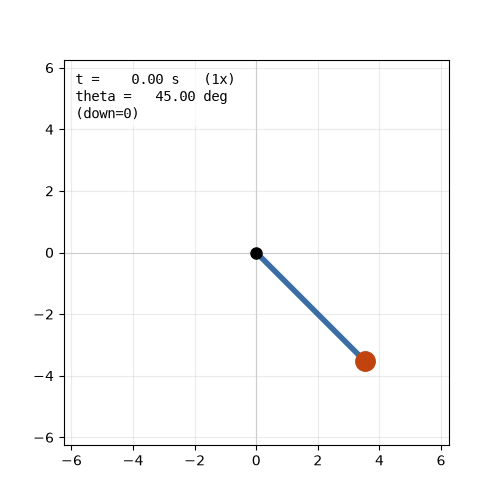

'pendulum.gif'

In [7]:
from viz import animate_pendulum

# inline HTML5 player in Jupyter:
animate_pendulum(pendulum.arm_thetas, arm_length=ARM_LENGTH,
                 units='rad', zero_ref='down', dt=DT)

In [29]:
def wrap_angle(e):
    return (e + math.pi) % (2 * math.pi) - math.pi

def clamp(value, smallest, largest):
    return max(smallest, min(value, largest))


class ReactionWheelSystem(System):

    def __init__(self, arm_length, arm_mass, arm_theta, wheel_mass, wheel_radius):
        
        super().__init__(arm_length, arm_mass, arm_theta)

        self.wheel_radius = wheel_radius
        self.wheel_mass = wheel_mass
        
        self.wheel_moment = self.wheel_mass * self.wheel_radius**2 # moment for a hoop (mass is all along radius r)
        self.wheel_torque = 0 # this is the motor input

        self.wheel_atheta = self.wheel_torque / self.wheel_moment
        self.wheel_vtheta = 0
        self.wheel_theta = 0


        self.wheel_athetas = []
        self.wheel_vthetas = []
        self.wheel_thetas = []

        self.errors = 0

    

    def wheel_torque_PID_response(self):
        desired_arm_theta = math.pi
        measured_arm_theta = self.arm_theta

        # it was suggested to wrap the error to (-pi, pi) instead of wrapping the actual theta (modding theta by 2*math.pi)
        error = wrap_angle(measured_arm_theta - desired_arm_theta)

        self.errors += error * DT
        
        i_term = KI * self.errors
        PID = KP * error + KD * self.arm_vtheta + (self.arm_torque) + i_term

        return PID


    

    def solve_for_theta(self):

        available_torque = WHEEL_TORQUE_MAX * (1 - abs(self.wheel_vtheta)/WHEEL_SPEED_MAX)

        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2) + (self.wheel_mass * self.arm_length**2)
        self.arm_torque = (self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)) + (self.wheel_mass * self.arm_length * GRAVITY * math.sin(self.arm_theta))

        # self.wheel_torque = self.wheel_torque_PID_response() # this is base PID signal without any torque limiting - assumes we have an infinitely commandable motor (no current/torque limit).
        # self.wheel_torque = clamp(self.wheel_torque_PID_response(), -WHEEL_TORQUE_MAX, WHEEL_TORQUE_MAX) # this version of wheel_torque signal is a simplified torque limit (can only command so much torque)
        self.wheel_torque = clamp(self.wheel_torque_PID_response(), -available_torque, available_torque) # this version of wheel_torque signal is based on the back-emf generated by increased wheel speed that limits the amount of toruqe we can command. at vtheta = 0, we can command max_torquqe, but at vtheta = max_speed, we can command 0 torque

        self.wheel_atheta = self.wheel_torque / self.wheel_moment
        self.wheel_vtheta = self.wheel_vtheta + self.wheel_atheta * DT
        self.wheel_theta = self.wheel_theta + self.wheel_vtheta * DT

        self.arm_atheta = (self.arm_torque + (-1 * self.wheel_torque) + FRICTION * (0 if self.arm_vtheta == 0 else 1) * (-1 if self.arm_vtheta > 0 else 1)) / self.arm_moment
        self.arm_vtheta = self.arm_vtheta + self.arm_atheta * DT
        self.arm_theta = (self.arm_theta + self.arm_vtheta * DT) % (2*math.pi)

        self.arm_athetas.append(self.arm_atheta)
        self.arm_vthetas.append(self.arm_vtheta)
        self.arm_thetas.append(self.arm_theta)

        self.wheel_athetas.append(self.wheel_atheta)
        self.wheel_vthetas.append(self.wheel_vtheta)
        self.wheel_thetas.append(self.wheel_theta)
        

    def loop(self, n):
        for i in range(n):
            self.solve_for_theta()



In [38]:
from viz import animate_system

ARM_LENGTH = 5.0
ARM_MASS = 5.0

WHEEL_MASS = 8.0
WHEEL_RADIUS = 2.0
WHEEL_TORQUE_MAX = 180
WHEEL_SPEED_MAX = 50

STARTING_ARM_THETA = math.radians(45) # in rad

GRAVITY = -9.8
FRICTION = 1.0

DT = 0.01

KP = 350
KD = 250
KI = 0.0

rwp = ReactionWheelSystem(ARM_LENGTH, ARM_MASS, STARTING_ARM_THETA, WHEEL_MASS, WHEEL_RADIUS)
rwp.loop(10000)

In [39]:
animate_system(rwp, units='rad', zero_ref='down', full=False, save_path = "pendulum.mp4", dt=DT)   # reaction wheel

saved -> pendulum.mp4
  window 0.0-20.0s of 100s sim | 1x speed | 600 frames @ 30fps = 20.0s clip | 33 ms sim/frame
  (showing first 20s only. For the whole run: full=True)


'pendulum.mp4'